{
    'topic': '猫咪',
    'poem': 
'好的，这里有一首关于猫咪的诗：\n\n**《猫》**\n\n身披一件柔软的衣裳，\n悄然无声，踱步在厅堂。\n琥珀的眼，闪烁着微光
，\n是家中一道温柔的月光。\n\n喜欢蜷缩在阳光下小憩，\n世界喧嚣，与它毫无关系。\n喉咙深处，发出咕噜的低语，\n那是满
足，也是幸福的标记。\n\n有时又化身灵巧的猎手，\n追逐线球，眼神专注不休。\n轻盈一跃，从沙发到窗头，\n每个动作都带着
诗意自由。\n\n它有它的骄傲，不轻易讨好，\n却也懂得，在你身边撒娇。\n用头轻蹭，一声软软的喵，\n便融化了，你所有的烦
恼。\n\n无论是慵懒，还是活泼跳跃，\n猫咪，总是家中温柔的焦点。\n用它独特的方式，默默陪伴，\n是生活中，最美的温柔画
面。',
    'joke': '好的，来一个猫咪主题的笑话：\n\n**问：** 为什么猫咪总是那么着急着吃饭？\n\n**答：** 
因为它们觉得，“喵~” 就是 “要~”！'
}

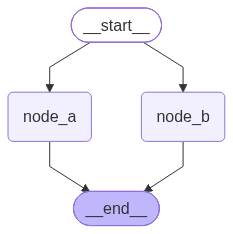

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	__start__ --> node_b;
	node_a --> __end__;
	node_b --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from rich import print as rprint
import os

from dotenv import load_dotenv
load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node(node_a)
builder.add_node(node_b)
builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")

builder.add_edge("node_b",END)
builder.add_edge("node_a",END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
rprint(res)

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)
